# Day 10 — Putting It All Together: Annual Energy + BEE Star Rating
**Mahesha Gonal — Refrigeration Simulation Portfolio**

**Note on this version:** the original Day 10 script combined every model built so far (condenser sizing from Day 9, capillary tube sizing from Day 8, the cycle function from Day 5) into one full calculator — but it only ever printed three scenarios as text, with no chart. This notebook adds a bar chart so the three scenarios can be compared at a glance.

**In plain terms:** this calculator answers the question a product manager actually asks: *"given this condenser size, this cap tube length, and this climate, what star rating does the fridge land at?"* It runs three realistic scenarios:

1. A well-sized condenser in a normal climate (32°C ambient, 0.6 m² condenser)
2. A **hot climate, undersized condenser** (42°C ambient, only 0.35 m²) — a cost-cutting, hot-region scenario
3. A **larger, well-sized condenser** even in the same normal climate (32°C ambient, 0.9 m²) — a premium-cost scenario

In [1]:
# CELL 1 — Install dependencies (run this first, every time)
!pip install coolprop matplotlib numpy PyGithub -q

In [2]:
# CELL 2 — Imports
import CoolProp.CoolProp as CP
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# CELL 3 — Building blocks: cycle function, condenser model, cap tube model, star rating
def calculate_cycle(T_evap_C, T_cond_C, refrigerant="R600a"):
    T_evap = T_evap_C + 273.15
    T_cond = T_cond_C + 273.15
    P_evap = CP.PropsSI("P","T",T_evap,"Q",1,refrigerant)
    P_cond = CP.PropsSI("P","T",T_cond,"Q",1,refrigerant)
    h1 = CP.PropsSI("H","T",T_evap,"Q",1,refrigerant)
    s1 = CP.PropsSI("S","T",T_evap,"Q",1,refrigerant)
    h2 = CP.PropsSI("H","P",P_cond,"S",s1,refrigerant)
    h3 = CP.PropsSI("H","T",T_cond,"Q",0,refrigerant)
    h4 = h3
    COP = (h1-h4)/(h2-h1)
    m_dot = 100/(h1-h4)
    return COP, m_dot, h1, h2, h3, h4, P_evap, P_cond

def get_condensing_temp(T_ambient, Q_cond, U, A):
    return T_ambient + Q_cond/(U*A)

def get_evap_temp(L_cap, L_ref, T_evap_ref_C, T_cond_C, refrigerant):
    P_cond_ref = CP.PropsSI("P","T",T_cond_C+273.15,"Q",1,refrigerant)
    P_evap_ref = CP.PropsSI("P","T",T_evap_ref_C+273.15,"Q",1,refrigerant)
    dP_per_m   = (P_cond_ref - P_evap_ref)/L_ref
    P_evap_new = P_cond_ref - (dP_per_m*L_cap)
    if P_evap_new <= 0: return None
    return CP.PropsSI("T","P",P_evap_new,"Q",1,refrigerant) - 273.15

def get_star_rating(aec):
    if aec > 300:   return 1,"1★"
    elif aec > 250: return 2,"2★"
    elif aec > 200: return 3,"3★"
    elif aec > 160: return 4,"4★"
    else:           return 5,"5★"

In [4]:
# CELL 4 — Full annual energy calculator
def full_annual_energy_calculator(refrigerant="R600a", T_ambient=32,
        A_cond=0.6, L_cap=3.0, Q_load=80, U_cond=20, verbose=True):
    Q_cond   = Q_load + Q_load/2.5
    T_cond_C = get_condensing_temp(T_ambient, Q_cond, U_cond, A_cond)
    if T_cond_C >= 130 or T_cond_C <= T_ambient: return None
    T_evap_C = get_evap_temp(L_cap, 3.0, -25, T_cond_C, refrigerant)
    if T_evap_C is None: return None
    try:
        COP,m_dot,h1,h2,h3,h4,P_evap,P_cond = calculate_cycle(T_evap_C,T_cond_C,refrigerant)
    except: return None
    W_comp = Q_load/COP
    annual_energy = (W_comp*(Q_load/100)*8760)/1000
    stars, star_str = get_star_rating(annual_energy)
    if verbose:
        print(f"T_cond={T_cond_C:.1f}C | T_evap={T_evap_C:.1f}C | COP={COP:.3f} | "
              f"AEC={annual_energy:.1f} kWh | {star_str}")
    return dict(T_cond_C=T_cond_C, T_evap_C=T_evap_C, COP=COP,
                W_comp=W_comp, annual_energy=annual_energy,
                stars=stars, star_str=star_str)

# Run three scenarios
print("Scenario 1 — Normal climate, well-sized condenser:")
r1 = full_annual_energy_calculator(T_ambient=32, A_cond=0.6)
print("\nScenario 2 — Hot climate, undersized condenser:")
r2 = full_annual_energy_calculator(T_ambient=42, A_cond=0.35)
print("\nScenario 3 — Normal climate, larger condenser:")
r3 = full_annual_energy_calculator(T_ambient=32, A_cond=0.9)

Scenario 1 — Normal climate, well-sized condenser:
T_cond=41.3C | T_evap=-25.0C | COP=2.664 | AEC=210.4 kWh | 3★

Scenario 2 — Hot climate, undersized condenser:
T_cond=58.0C | T_evap=-25.0C | COP=1.802 | AEC=311.1 kWh | 1★

Scenario 3 — Normal climate, larger condenser:
T_cond=38.2C | T_evap=-25.0C | COP=2.868 | AEC=195.5 kWh | 4★


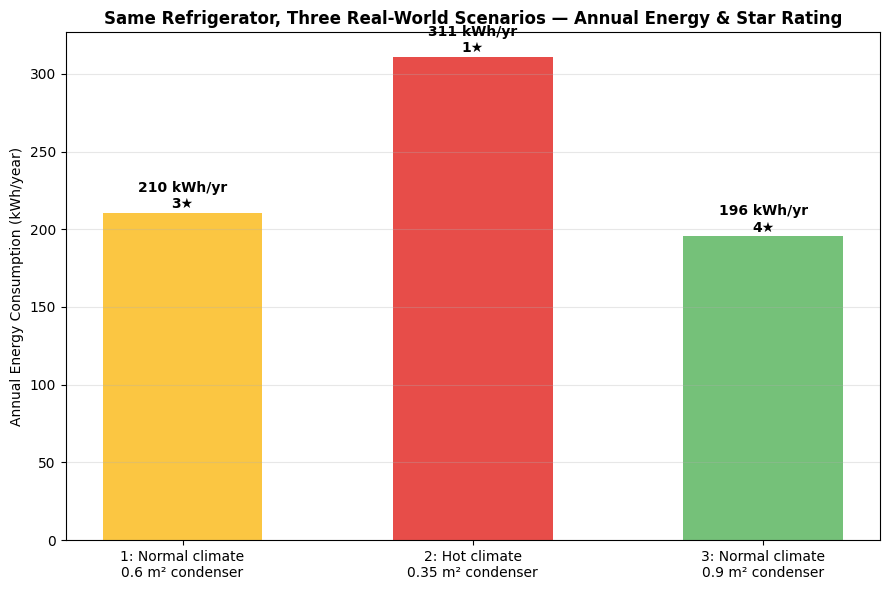

In [5]:
# CELL 5 — Bar chart comparing the three scenarios (this is the chart Day 10 was missing)
scenarios = ["1: Normal climate\n0.6 m\u00b2 condenser", "2: Hot climate\n0.35 m\u00b2 condenser",
             "3: Normal climate\n0.9 m\u00b2 condenser"]
results = [r1, r2, r3]
aec_vals = [r["annual_energy"] for r in results]
star_labels = [r["star_str"] for r in results]
colors = {5:"#2E7D32", 4:"#66BB6A", 3:"#FBC02D", 2:"#FB8C00", 1:"#E53935"}
bar_colors = [colors[r["stars"]] for r in results]

fig, ax = plt.subplots(figsize=(9,6))
bars = ax.bar(scenarios, aec_vals, color=bar_colors, alpha=0.9, width=0.55)
for bar, aec, star in zip(bars, aec_vals, star_labels):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
            f"{aec:.0f} kWh/yr\n{star}", ha="center", fontsize=10, fontweight="bold")

ax.set_ylabel("Annual Energy Consumption (kWh/year)")
ax.set_title("Same Refrigerator, Three Real-World Scenarios — Annual Energy & Star Rating",
             fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("day10_scenario_comparison.png", dpi=150)
plt.show()

**What this chart tells us:** the *exact same refrigerator design* swings between star ratings purely because of climate and condenser sizing — nothing about the compressor or refrigerant changed between bars. Scenario 2 (hot climate + cost-cut condenser) is the realistic failure mode: a unit that earns a 3-star rating in BEE's standard test ambient can drop all the way to 1-star in a genuinely hot Indian summer with an undersized heat exchanger — a two-band swing from climate and sizing alone. This is the single chart that ties Days 5 through 9 into one business-relevant number.

In [ ]:
# FINAL CELL — Push this notebook to GitHub
from github import Github, Auth
from google.colab import userdata, _message
import json

token = userdata.get('GITHUB_TOKEN')
auth = Auth.Token(token)
g = Github(auth=auth)
repo = g.get_repo("MaheshaGonal/refrigeration-simulation-python")

nb_data = _message.blocking_request('get_ipynb', request='', timeout_sec=30)
content = json.dumps(nb_data['ipynb'], indent=1)

filename = "day10_annual_energy_calculator.ipynb"

try:
    existing = repo.get_contents(filename)
    repo.update_file(filename, "Add Day 10 - full annual energy calculator + BEE star rating (adds scenario chart)", content, existing.sha)
    print("Updated existing file on GitHub")
except Exception:
    repo.create_file(filename, "Add Day 10 - full annual energy calculator + BEE star rating (adds scenario chart)", content)
    print("Created new file on GitHub")

print("GitHub repo: https://github.com/MaheshaGonal/refrigeration-simulation-python")
